In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import shap

print("All necessary libraries have been imported.")

All necessary libraries have been imported.


In [2]:
# check which datasets can be imported
# list_available_datasets()

# import dataset
df = fetch_ucirepo(id=296)

# access data
X = df.data.features
y = df.data.targets
# train model e.g. sklearn.linear_model.LinearRegression().fit(X, y)

# access metadata
print(df.metadata.uci_id)
print(df.metadata.num_instances)
print(df.metadata.additional_info.summary)

# access variable info in tabular format
# print(df.variables)

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


296
101766
The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. It includes over 50 features representing patient and hospital outcomes. Information was extracted from the database for encounters that satisfied the following criteria.
(1)	It is an inpatient encounter (a hospital admission).
(2)	It is a diabetic encounter, that is, one during which any kind of diabetes was entered into the system as a diagnosis.
(3)	The length of stay was at least 1 day and at most 14 days.
(4)	Laboratory tests were performed during the encounter.
(5)	Medications were administered during the encounter.

The data contains such attributes as patient number, race, gender, age, admission type, time in hospital, medical specialty of admitting physician, number of lab tests performed, HbA1c test result, diagnosis, number of medications, diabetic medications, number of outpatient, inpatient, and emergency visits in the year before the hospitalizati

In [3]:
# Access the features and targets
X = df.data.features
y = df.data.targets

# Describe the features DataFrame
display(X.describe())

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [4]:
# Initial data setup
full_df = pd.concat([X, y], axis=1)
full_df.replace('?', np.nan, inplace=True)
df_cleaned = full_df.copy()

In [5]:
missing_values = df_cleaned.isnull().sum()
missing_percentage = (missing_values / len(df_cleaned)) * 100
missing_info = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

# Display the result
print("Percentage of missing values per column:\n")
print(missing_info)

Percentage of missing values per column:

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


Handle missing values

In [6]:

df_cleaned.drop(columns=['weight', 'max_glu_serum', 'A1Cresult'], inplace=True)
df_cleaned[['medical_specialty', 'payer_code']] = df_cleaned[['medical_specialty', 'payer_code']].fillna('Unknown')
df_cleaned['race'].fillna(df_cleaned['race'].mode()[0], inplace=True)
df_cleaned.dropna(subset=['diag_1', 'diag_2', 'diag_3'], inplace=True)

/tmp/ipython-input-1531877463.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['race'].fillna(df_cleaned['race'].mode()[0], inplace=True)


Simplify ICD-9 diagnosis codes into major categories

In [7]:

df_processed = df_cleaned.copy()
def classify_diagnosis(diag_code):
    diag_code_str = str(diag_code)
    if diag_code_str.startswith('E') or diag_code_str.startswith('V'): return 'Other'
    try:
        code = float(diag_code_str)
        if 390 <= code <= 459 or code == 785: return 'Circulatory'
        elif 460 <= code <= 519 or code == 786: return 'Respiratory'
        elif 520 <= code <= 579 or code == 787: return 'Digestive'
        elif 250 <= code <= 250.99: return 'Diabetes'
        elif 800 <= code <= 999: return 'Injury'
        elif 710 <= code <= 739: return 'Musculoskeletal'
        elif 580 <= code <= 629 or code == 788: return 'Genitourinary'
        elif 140 <= code <= 239: return 'Neoplasms'
        else: return 'Other'
    except ValueError: return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df_processed[col] = df_processed[col].apply(classify_diagnosis)
df_processed.rename(columns={'diag_1': 'primary_diagnosis', 'diag_2': 'secondary_diagnosis', 'diag_3': 'additional_diagnosis'}, inplace=True)


Create and filter the multi-class target variable

In [8]:
def group_and_filter_discharge_disposition(df):
    df_temp = df.copy()
    discharge_map = {1: "Home", 2: "Short-term hospital", 3: "Skilled nursing facility", 4: "Intermediate care", 5: "Another inpatient care", 6: "Home with health service"}
    df_temp['discharge_disposition_text'] = df_temp['discharge_disposition_id'].map(discharge_map).fillna("Other/Unknown")
    def group_disposition(disposition_text):
        if disposition_text in ['Home', 'Home with health service']: return 'Discharged Home'
        elif disposition_text in ['Short-term hospital', 'Another inpatient care']: return 'Transferred to Another Hospital'
        elif disposition_text in ['Skilled nursing facility', 'Intermediate care']: return 'Transferred to Facility-Based Care'
        else: return 'Other'
    df_temp['discharge_disposition_grouped'] = df_temp['discharge_disposition_text'].apply(group_disposition)
    df_filtered = df_temp[df_temp['discharge_disposition_grouped'].isin(['Discharged Home', 'Transferred to Another Hospital', 'Transferred to Facility-Based Care'])].copy()
    return df_filtered

data_multiclass = group_and_filter_discharge_disposition(df_processed)

Select features and separate X/y

In [9]:
feat_col = [
    'race', 'gender', 'age', 'admission_type_id', 'admission_source_id',
    'primary_diagnosis', 'secondary_diagnosis', 'additional_diagnosis',
    'medical_specialty', 'number_outpatient', 'number_inpatient',
    'number_emergency', 'number_diagnoses', 'num_procedures',
    'num_lab_procedures', 'num_medications', 'change', 'diabetesMed'
]
X = data_multiclass[feat_col]
y_cls = data_multiclass['discharge_disposition_grouped']
y_reg = data_multiclass['time_in_hospital']

# Split data into training and testing sets before encoding
X_train, X_test, y_train, y_test = train_test_split(X, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

Encoding

In [10]:
# Ordinal for age
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_encoder = preprocessing.OrdinalEncoder(categories=[age_order])
X_train['age'] = age_encoder.fit_transform(X_train[['age']])
X_test['age'] = age_encoder.transform(X_test[['age']])

# Binary for binary features
for df in [X_train, X_test]:
    df['change'] = df['change'].map({'Ch': 1, 'No': 0})
    df['diabetesMed'] = df['diabetesMed'].map({'Yes': 1, 'No': 0})
    df['gender'] = df['gender'].map({'Male': 1, 'Female': 0, 'Unknown/Invalid': -1})

# One-Hot for remaining nominal features
categorical_cols = X_train.select_dtypes(include='object').columns
one_hot_enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_enc = one_hot_enc.fit_transform(X_train[categorical_cols])
X_test_enc = one_hot_enc.transform(X_test[categorical_cols])

In [11]:
X_train_enc_df = pd.DataFrame(X_train_enc, columns=one_hot_enc.get_feature_names_out(categorical_cols), index=X_train.index)
X_test_enc_df = pd.DataFrame(X_test_enc, columns=one_hot_enc.get_feature_names_out(categorical_cols), index=X_test.index)

X_train_processed = X_train.drop(columns=categorical_cols).join(X_train_enc_df)
X_test_processed = X_test.drop(columns=categorical_cols).join(X_test_enc_df)

print(f"Training features shape: {X_train_processed.shape}")
print(f"testing features shape: {X_test_processed.shape}")

Training features shape: (71855, 116)
testing features shape: (17964, 116)


In [12]:
y_train_reg = y_reg.loc[X_train.index]
y_test_reg = y_reg.loc[X_test.index]

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"y_train_reg shape: {y_train_reg.shape}")

X_train_processed shape: (71855, 116)
y_train_reg shape: (71855,)


Regression part

In [13]:
print("--- Linear Regression ---")

model_lin_reg = LinearRegression()
model_lin_reg.fit(X_train_processed, y_train_reg)
y_pred_lin = model_lin_reg.predict(X_test_processed)


r2_lin = r2_score(y_test_reg, y_pred_lin)
mae_lin = mean_absolute_error(y_test_reg, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test_reg, y_pred_lin))

print(f"R-squared (R²): {r2_lin:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lin:.4f} (day)")
print(f"Root Mean Squared Error (RMSE): {rmse_lin:.4f}")

--- Linear Regression ---
R-squared (R²): 0.3256
Mean Absolute Error (MAE): 1.8321 (day)
Root Mean Squared Error (RMSE): 2.4182


In [14]:
print("--- HistGradientBoostingRegressor ---")


hgbr = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=1000,
    min_samples_leaf=30,
    random_state=42
)

hgbr.fit(X_train_processed, y_train_reg)
y_pred_hgbr = hgbr.predict(X_test_processed)

r2_hgbr = r2_score(y_test_reg, y_pred_hgbr)
mae_hgbr = mean_absolute_error(y_test_reg, y_pred_hgbr)
rmse_hgbr = np.sqrt(mean_squared_error(y_test_reg, y_pred_hgbr))

print(f"R-squared (R²): {r2_hgbr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_hgbr:.4f} (day)")
print(f"Root Mean Squared Error (RMSE): {rmse_hgbr:.4f}")

--- HistGradientBoostingRegressor ---
R-squared (R²): 0.3990
Mean Absolute Error (MAE): 1.7121 (day)
Root Mean Squared Error (RMSE): 2.2828


In [15]:
print("--- Random Forest Regressor - orginal ---")

rf_reg_baseline = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_reg_baseline.fit(X_train_processed, y_train_reg)
y_pred_rf_baseline = rf_reg_baseline.predict(X_test_processed)

r2_rf_baseline = r2_score(y_test_reg, y_pred_rf_baseline)
mae_rf_baseline = mean_absolute_error(y_test_reg, y_pred_rf_baseline)
rmse_rf_baseline = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_baseline))

print(f"R-squared (R²): {r2_rf_baseline:.4f}")
print(f"Mean Absolute Error (MAE): {mae_rf_baseline:.4f} (天)")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_baseline:.4f}")


print("\n--- Random Forest Regressor - tuned ---")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_reg = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(estimator=rf_reg,
                                   param_distributions=param_grid,
                                   n_iter=10,
                                   cv=3,
                                   verbose=2,
                                   random_state=42,
                                   n_jobs=-1)

random_search.fit(X_train_processed, y_train_reg)
best_rf_model = random_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test_processed)

r2_best_rf = r2_score(y_test_reg, y_pred_best_rf)
mae_best_rf = mean_absolute_error(y_test_reg, y_pred_best_rf)
rmse_best_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_best_rf))

print(f"Tuned R-squared (R²): {r2_best_rf:.4f}")
print(f"Tuned Mean Absolute Error (MAE): {mae_best_rf:.4f} (day)")
print(f"Tuned Root Mean Squared Error (RMSE): {rmse_best_rf:.4f}")

--- Random Forest Regressor - orginal ---
R-squared (R²): 0.3729
Mean Absolute Error (MAE): 1.7541 (天)
Root Mean Squared Error (RMSE): 2.3319

--- Random Forest Regressor - tuned ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Tuned R-squared (R²): 0.3773
Tuned Mean Absolute Error (MAE): 1.7583 (day)
Tuned Root Mean Squared Error (RMSE): 2.3236


--- Generating SHAP Explanations---


 99%|===================| 17871/17964 [03:25<00:01]       

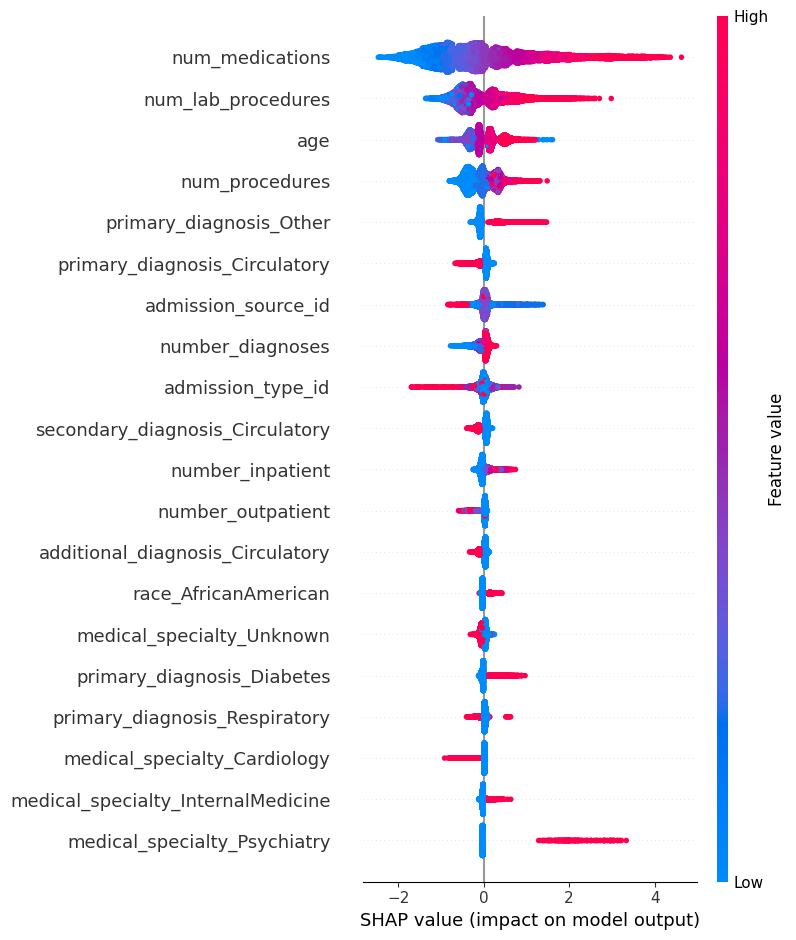

In [16]:
print("--- Generating SHAP Explanations---")

explainer = shap.TreeExplainer(hgbr, X_train_processed)
shap_values = explainer(X_test_processed)


shap.summary_plot(shap_values, X_test_processed, plot_type="dot")

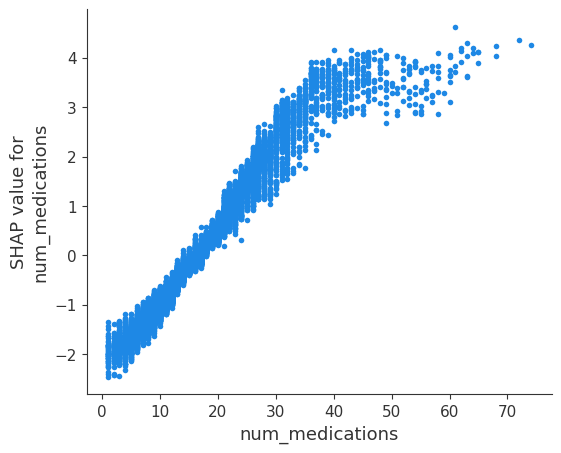

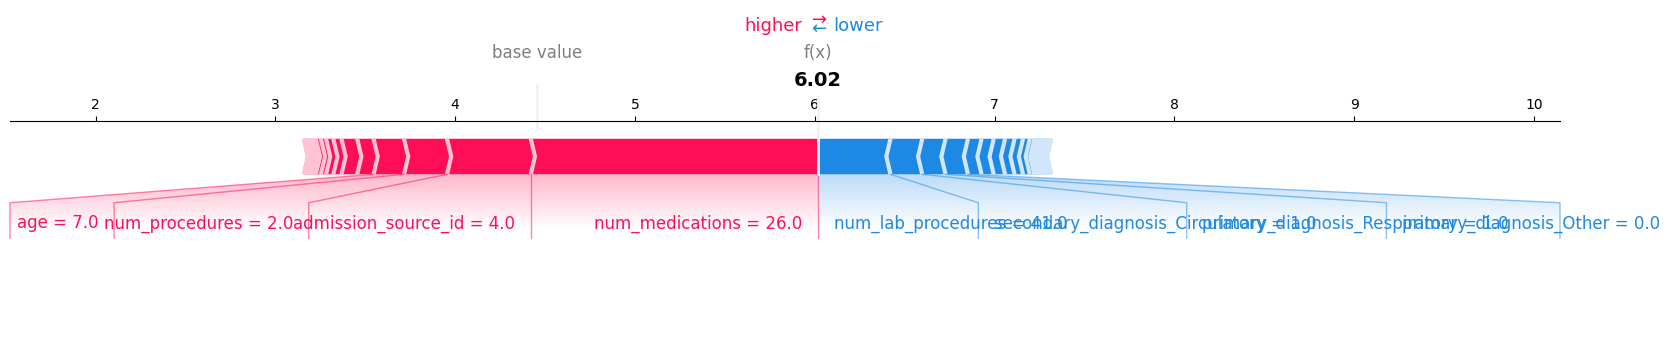

In [17]:
shap.dependence_plot("num_medications", shap_values.values, X_test_processed, interaction_index=None)

shap.initjs()
shap.force_plot(explainer.expected_value, shap_values.values[0,:], X_test_processed.iloc[0,:])

force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values.values[0,:],
    X_test_processed.iloc[0,:],
    matplotlib=True,
    show=False
)

force_plot.savefig('shap_force_plot_single.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

classification part

In [18]:
print("--- Decision Tree Classifier ---")

dt_class = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

dt_class.fit(X_train_processed, y_train)
y_pred_dt = dt_class.predict(X_test_processed)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

--- Decision Tree Classifier ---

Classification Report:
                                    precision    recall  f1-score   support

                   Discharged Home       0.92      0.43      0.59     14367
   Transferred to Another Hospital       0.06      0.46      0.11       656
Transferred to Facility-Based Care       0.32      0.68      0.43      2941

                          accuracy                           0.47     17964
                         macro avg       0.43      0.52      0.38     17964
                      weighted avg       0.79      0.47      0.55     17964

Confusion Matrix:
[[6222 4038 4107]
 [ 171  302  183]
 [ 348  602 1991]]

Accuracy: 0.4740


In [19]:
print("--- Random Forest Classifier ---")

rf_class = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_class.fit(X_train_processed, y_train)
y_pred_rf = rf_class.predict(X_test_processed)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

--- Random Forest Classifier ---

Classification Report:
                                    precision    recall  f1-score   support

                   Discharged Home       0.90      0.74      0.81     14367
   Transferred to Another Hospital       0.13      0.22      0.16       656
Transferred to Facility-Based Care       0.39      0.66      0.49      2941

                          accuracy                           0.71     17964
                         macro avg       0.47      0.54      0.49     17964
                      weighted avg       0.79      0.71      0.74     17964

Confusion Matrix:
[[10648   894  2825]
 [  356   147   153]
 [  887   111  1943]]

Accuracy: 0.7091


In [20]:
print("--- XGBoost Classifier ---")

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

xgb_class = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_class.fit(X_train_processed, y_train_encoded)
y_pred_xgb_encoded = xgb_class.predict(X_test_processed)
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

--- XGBoost Classifier ---

Classification Report:
                                    precision    recall  f1-score   support

                   Discharged Home       0.84      0.97      0.90     14367
   Transferred to Another Hospital       0.27      0.00      0.01       656
Transferred to Facility-Based Care       0.63      0.29      0.40      2941

                          accuracy                           0.82     17964
                         macro avg       0.58      0.42      0.43     17964
                      weighted avg       0.78      0.82      0.78     17964

Confusion Matrix:
[[13892     4   471]
 [  612     3    41]
 [ 2083     4   854]]

Accuracy: 0.8210


In [21]:
print("--- Logistic Regression ---")
log_reg_class = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

log_reg_class.fit(X_train_processed, y_train)

y_pred_log_reg = log_reg_class.predict(X_test_processed)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")

--- Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Classification Report:
                                    precision    recall  f1-score   support

                   Discharged Home       0.92      0.51      0.66     14367
   Transferred to Another Hospital       0.07      0.48      0.12       656
Transferred to Facility-Based Care       0.37      0.68      0.48      2941

                          accuracy                           0.54     17964
                         macro avg       0.45      0.56      0.42     17964
                      weighted avg       0.80      0.54      0.61     17964

Confusion Matrix:
[[7342 3773 3252]
 [ 195  315  146]
 [ 431  499 2011]]

Accuracy: 0.5382


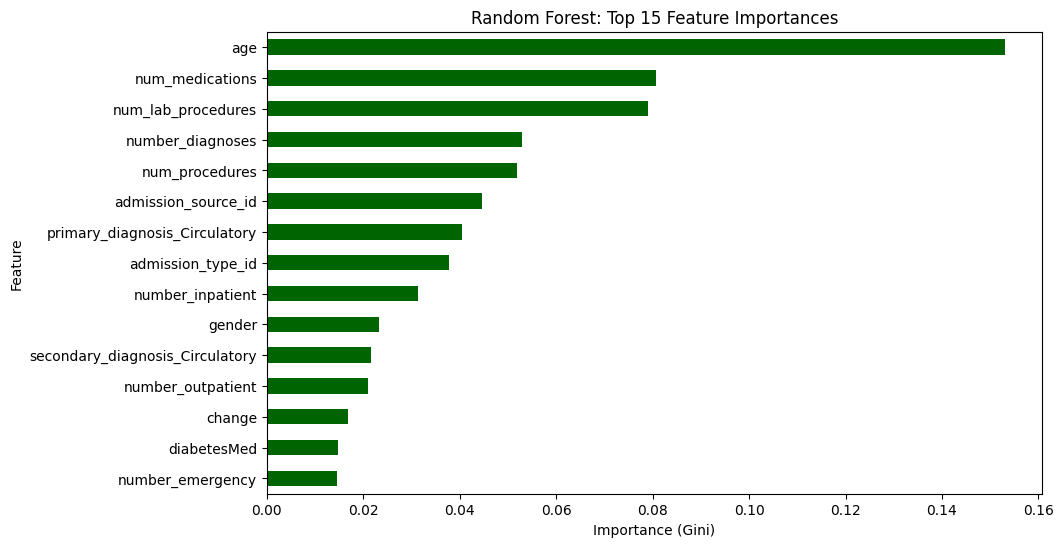

In [22]:
# Extract feature importances
rf_importances = pd.Series(rf_class.feature_importances_, index=X_train_processed.columns)

# Get the top 15 features
rf_top_15 = rf_importances.nlargest(15)


plt.figure(figsize=(10, 6))
rf_top_15.sort_values().plot(kind='barh', color='darkgreen')
plt.title('Random Forest: Top 15 Feature Importances')
plt.xlabel('Importance (Gini)')
plt.ylabel('Feature')
plt.show()

100%|===================| 2999/3000 [12:54<00:00]       

Shape of shap_values: (1000, 116, 3)
Shape of X_test_sample: (1000, 116)
Columns of X_test_sample: ['gender', 'age', 'admission_type_id', 'admission_source_id', 'number_outpatient', 'number_inpatient', 'number_emergency', 'number_diagnoses', 'num_procedures', 'num_lab_procedures', 'num_medications', 'change', 'diabetesMed', 'race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'primary_diagnosis_Circulatory', 'primary_diagnosis_Diabetes', 'primary_diagnosis_Digestive', 'primary_diagnosis_Genitourinary', 'primary_diagnosis_Injury', 'primary_diagnosis_Musculoskeletal', 'primary_diagnosis_Neoplasms', 'primary_diagnosis_Other', 'primary_diagnosis_Respiratory', 'secondary_diagnosis_Circulatory', 'secondary_diagnosis_Diabetes', 'secondary_diagnosis_Digestive', 'secondary_diagnosis_Genitourinary', 'secondary_diagnosis_Injury', 'secondary_diagnosis_Musculoskeletal', 'secondary_diagnosis_Neoplasms', 'secondary_diagnosis_Other', 'secondary_diagnosis_Respiratory',

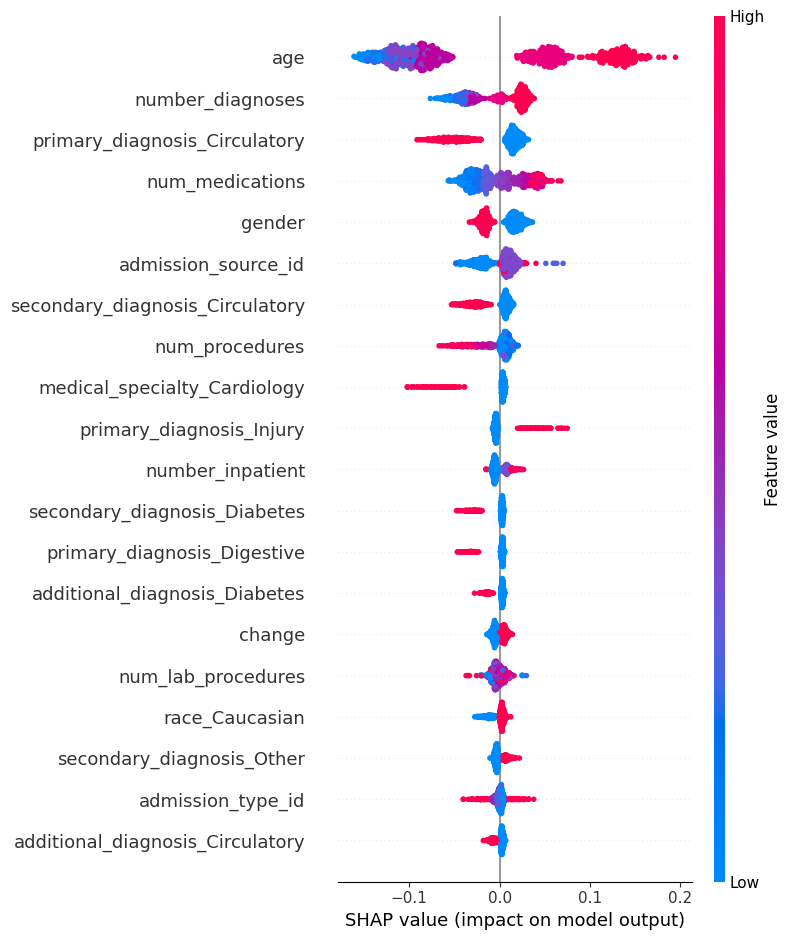


Explaining Prediction for Patient 0 (Class 2: Facility Care)


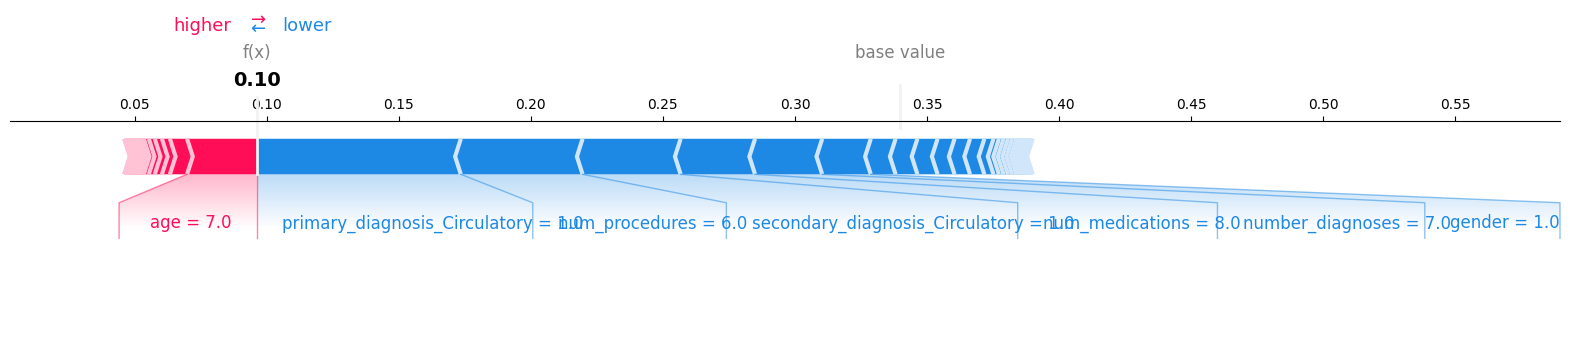

In [23]:


# --- A. Prepare the SHAP Explainer (for XGBoost) ---

explainer = shap.Explainer(rf_class, X_train_processed.sample(n=100, random_state=42))

X_test_sample = X_test_processed.sample(n=1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# --- B. Global Interpretation: SHAP Summary Plot ---

print("Shape of shap_values:", shap_values.shape) # Print shape of the main shap_values object
print("Shape of X_test_sample:", X_test_sample.shape)
print("Columns of X_test_sample:", X_test_sample.columns.tolist())
print("label_encoder.classes_:", label_encoder.classes_)

shap.summary_plot(shap_values[:, :, 2], X_test_sample, class_names=label_encoder.classes_)


# --- C. Local Interpretation: Force Plot for a Single Patient ---

# Select the first patient in the sample (index 0)
patient_index = 0
patient_features = X_test_sample.iloc[patient_index]

print(f"\nExplaining Prediction for Patient {patient_index} (Class 2: Facility Care)")
shap.initjs()
shap.force_plot(
    explainer.expected_value[2],
    shap_values[patient_index, :, 2],
    patient_features,
    matplotlib=True,
    show=True
)